# Modelling

## Models to Be Tested

| Model | Features | Purpose |
|---|---|---|
| **RFM Baseline** | Log-transformed and standardised Recency, Frequency, Monetary | Initial benchmark using the classical RFM framework |
| **Robust RFM** | Valid customer records; p99-capped Frequency and Monetary; log-transformed and standardised RFM features | Limit the influence of extreme observations in K-Means and create a robust, interpretable core segmentation |
| **Robust RFM + NLP** | Robust RFM features + TF-IDF product-description features reduced with Truncated SVD | Test whether product-preference information improves customer segmentation beyond RFM |
| **Robust RFM + Behaviour** | Robust RFM features + purchase-timing and purchase-rhythm features | Test whether behavioural and temporal information improves customer segmentation |

In [151]:
# Imports

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [152]:
# Load Data

df = pd.read_csv('../01_data/02_processed_data/customer_profile.csv')
df.head()

,CustomerID,recency,frequency,monetary,weekend_share,avg_purchase_hour,preferred_hour,preferred_weekday,active_purchase_days,preferred_time_5cat,...,text_svd_05,text_svd_06,text_svd_07,text_svd_08,text_svd_09,text_svd_10,text_svd_11,text_svd_12,text_svd_13,text_svd_14
0,12346.0,326,12,77556.46,0.000,10.833333,13,0,8,midday,...,-0.054787,-0.021104,0.195492,0.084543,0.104115,-0.240231,0.245742,0.311689,0.199950,-0.054729
1,12347.0,2,8,5633.32,0.125,12.500000,14,1,8,afternoon,...,-0.112825,0.064833,-0.152168,0.155788,-0.040855,-0.156677,0.061693,-0.027149,-0.060058,0.173658
2,12348.0,75,5,2019.40,0.200,13.200000,10,1,5,midday,...,-0.161823,0.537691,-0.191536,0.081759,-0.091979,0.089767,-0.054764,0.083323,0.009273,0.111751
3,12349.0,19,4,4428.69,0.000,9.750000,9,3,4,morning,...,-0.186275,-0.166294,0.324660,-0.083427,0.013956,-0.200510,0.100400,0.139637,-0.129949,-0.048644
4,12350.0,310,1,334.40,0.000,16.000000,16,2,1,afternoon,...,0.124714,-0.115467,0.113825,-0.004743,-0.085082,0.096691,0.024741,-0.027823,-0.030778,-0.002321


### RFM Baseline

In [153]:
# Features Selection - Baseline RFM

rfm = ['recency', 'frequency', 'monetary']

rfm_log=[]

for col in rfm: 
    new_col = f"{col}_log"
    df[new_col] = np.log1p(df[col])
    rfm_log.append(new_col)
    print(new_col)
    print(df[new_col].describe())
    print('##############')

print(rfm_log)


recency_log
count    5879.000000
mean        4.453492
std         1.560043
min         0.693147
25%         3.295837
50%         4.574711
75%         5.942799
max         6.606650
Name: recency_log, dtype: float64
##############
frequency_log
count    5879.000000
mean        1.550692
std         0.813796
min         0.693147
25%         0.693147
50%         1.386294
75%         2.079442
max         8.042056
Name: frequency_log, dtype: float64
##############
monetary_log
count    5879.000000
mean        6.837936
std         1.391812
min         1.373716
25%         5.857290
50%         6.802350
75%         7.745024
max        14.987735
Name: monetary_log, dtype: float64
##############
['recency_log', 'frequency_log', 'monetary_log']


In [154]:
# Clustering

X = df[rfm_log]

preprocess = ColumnTransformer([
    ('scaler', StandardScaler(), rfm_log)
])

X_processed = preprocess.fit_transform(X)

n_components_to_test = range(2, 10)

inertias = []
silhouettes = []

for n in n_components_to_test:
    model = KMeans(n_clusters=n, random_state=42, n_init="auto")
    labels = model.fit_predict(X_processed)

    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_processed, labels))

results = pd.DataFrame({
    'k': list(n_components_to_test),
    'inertia': inertias,
    'silhouette': silhouettes
})


In [155]:
results

,k,inertia,silhouette
0,2,8620.579019,0.438884
1,3,6386.969759,0.347550
2,4,4955.740123,0.364701
3,5,4129.548196,0.343958
4,6,3584.091879,0.332019
5,7,3221.601853,0.316131
6,8,2932.791710,0.305595
7,9,2692.710339,0.294146


### Robust RFM

In [156]:
# Load Data

df = pd.read_csv('../01_data/02_processed_data/customer_profile_rfm_cap.csv')
df.head()

,CustomerID,recency,frequency,monetary,weekend_share,avg_purchase_hour,preferred_hour,preferred_weekday,active_purchase_days,preferred_time_5cat,...,text_svd_11,text_svd_12,text_svd_13,text_svd_14,recency_log,frequency_log,monetary_log,recency_log_cap,frequency_log_cap,monetary_log_cap
0,12346.0,326,12,29730.4202,0.000,10.833333,13,0,8,midday,...,0.245742,0.311689,0.199950,-0.054729,5.789960,2.564949,11.258774,5.789960,2.564949,10.299960
1,12347.0,2,8,5633.3200,0.125,12.500000,14,1,8,afternoon,...,0.061693,-0.027149,-0.060058,0.173658,1.098612,2.197225,8.636632,1.098612,2.197225,8.636632
2,12348.0,75,5,2019.4000,0.200,13.200000,10,1,5,midday,...,-0.054764,0.083323,0.009273,0.111751,4.330733,1.791759,7.611051,4.330733,1.791759,7.611051
3,12349.0,19,4,4428.6900,0.000,9.750000,9,3,4,morning,...,0.100400,0.139637,-0.129949,-0.048644,2.995732,1.609438,8.396085,2.995732,1.609438,8.396085
4,12350.0,310,1,334.4000,0.000,16.000000,16,2,1,afternoon,...,0.024741,-0.027823,-0.030778,-0.002321,5.739793,0.693147,5.815324,5.739793,0.693147,5.815324


In [157]:
# Features Selection - Robust RFM

rfm_log_cap=['recency_log_cap', 'frequency_log_cap', 'monetary_log_cap']


In [158]:
# Clustering

X = df[rfm_log_cap]

preprocess = ColumnTransformer([
    ('scaler', StandardScaler(), rfm_log_cap)
])

X_processed = preprocess.fit_transform(X)

n_components_to_test = range(2, 10)

inertias = []
silhouettes = []

for n in n_components_to_test:
    model = KMeans(n_clusters=n, random_state=42, n_init="auto")
    labels = model.fit_predict(X_processed)

    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_processed, labels))

results = pd.DataFrame({
    'k': list(n_components_to_test),
    'inertia': inertias,
    'silhouette': silhouettes
})


In [159]:
results

,k,inertia,silhouette
0,2,8440.617701,0.440107
1,3,6203.389336,0.349860
2,4,4759.755559,0.368794
3,5,3985.229604,0.336753
4,6,3427.468165,0.336136
5,7,3066.198019,0.306464
6,8,2782.248908,0.308357
7,9,2575.581157,0.287234


In [160]:
kmeans_2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

kmeans_4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

df["cluster_k2"] = kmeans_2.fit_predict(X_processed)
df["cluster_k4"] = kmeans_4.fit_predict(X_processed)

In [161]:
for cluster_col in ['cluster_k2', 'cluster_k4']:
    print(f"\n{cluster_col}: Cluster sizes")
    display(
        df[cluster_col]
        .value_counts()
        .sort_index()
        .to_frame('n_customers')
        .assign(
            pct=lambda x: (
                x['n_customers'] / x['n_customers'].sum() * 100
            ).round(1)
        )
    )

    print(f"\n{cluster_col}: RFM-Profile")
    display(
        df
        .groupby(cluster_col)[['recency', 'frequency', 'monetary']]
        .agg(['count', 'median', 'mean'])
        .round(2)
    )


cluster_k2: Cluster sizes


,n_customers,pct
cluster_k2,,
0,2345,39.9
1,3533,60.1



cluster_k2: RFM-Profile


recency                frequency               monetary           \
             count median    mean     count median   mean    count   median   
cluster_k2                                                                    
0             2345   24.0   52.33      2345    8.0  11.38     2345  2879.70   
1             3533  291.0  300.11      3533    2.0   2.07     3533   418.82   

                     
               mean  
cluster_k2           
0           4972.12  
1            614.43


cluster_k4: Cluster sizes


,n_customers,pct
cluster_k4,,
0,1238,21.1
1,1219,20.7
2,1457,24.8
3,1964,33.4



cluster_k4: RFM-Profile


recency                frequency               monetary           \
             count median    mean     count median   mean    count   median   
cluster_k4                                                                    
0             1238   24.0   29.01      1238    3.0   2.98     1238   730.12   
1             1219   17.0   27.76      1219   13.0  16.63     1219  5067.27   
2             1457  185.0  229.42      1457    4.0   5.04     1457  1495.98   
3             1964  405.0  396.63      1964    1.0   1.38     1964   281.90   

                     
               mean  
cluster_k4           
0            839.17  
1           7621.17  
2           1965.98  
3            324.28

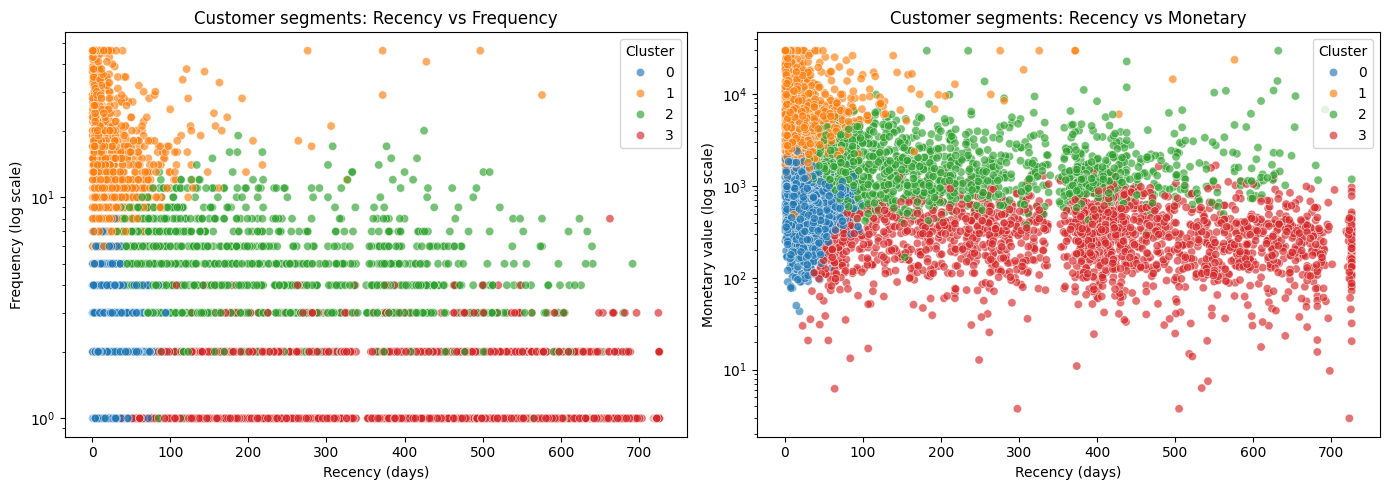

In [162]:
plot_df = df.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=plot_df,
    x='recency',
    y='frequency',
    hue='cluster_k4',
    palette='tab10',
    alpha=0.65,
    ax=axes[0]
)

axes[0].set_yscale('log')
axes[0].set_title('Customer segments: Recency vs Frequency')
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].legend(title='Cluster', loc='upper right')


sns.scatterplot(
    data=plot_df,
    x='recency',
    y='monetary',
    hue='cluster_k4',
    palette='tab10',
    alpha=0.65,
    ax=axes[1]
)

axes[1].set_yscale('log')
axes[1].set_title('Customer segments: Recency vs Monetary')
axes[1].set_xlabel('Recency (days)')
axes[1].set_ylabel('Monetary value (log scale)')
axes[1].legend(title='Cluster', loc='upper right')

plt.tight_layout()
plt.show()

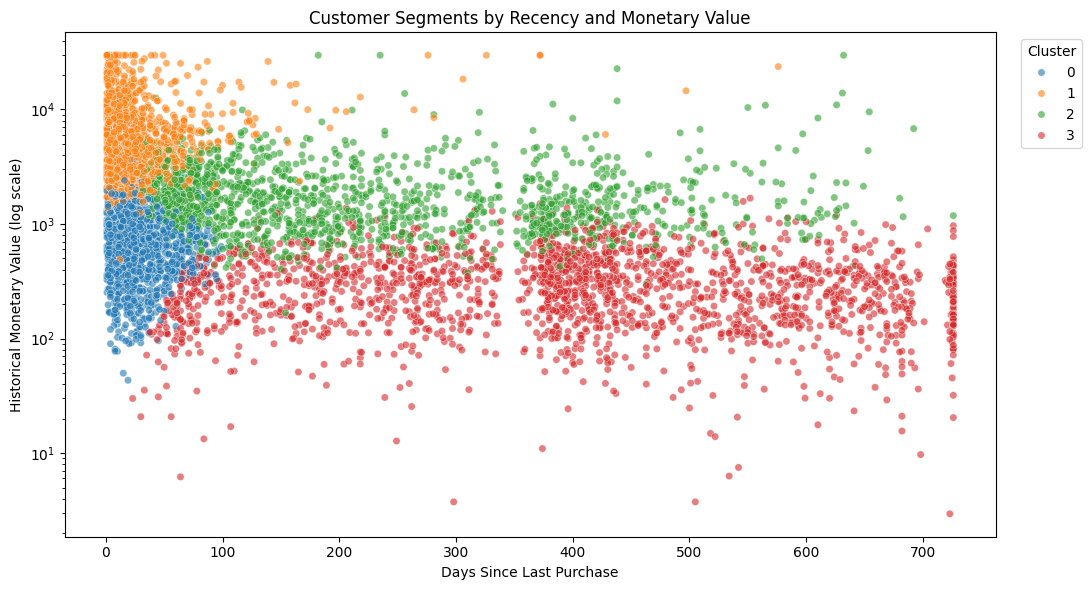

In [163]:
plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=df,
    x="recency",
    y="monetary",
    hue="cluster_k4",
    palette="tab10",
    alpha=0.60,
    s=28
)

plt.yscale("log")

plt.title("Customer Segments by Recency and Monetary Value")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Historical Monetary Value (log scale)")

plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [182]:
segment_names = {
    0: 'Recent Low-Value Buyers — Recent, low value',
    1: 'Champions — Recent, high value',
    2: 'At-Risk Mid-Value Buyers — Inactive, mid value',
    3: 'Dormant Low-Value Buyers — Inactive, low value'
}

df['segment'] = df['cluster_k4'].map(segment_names)

df["segment"].value_counts()


segment
Dormant Low-Value Buyers — Inactive, low value    1964
At-Risk Mid-Value Buyers — Inactive, mid value    1457
Recent Low-Value Buyers — Recent, low value       1238
Champions — Recent, high value                    1219
Name: count, dtype: int64

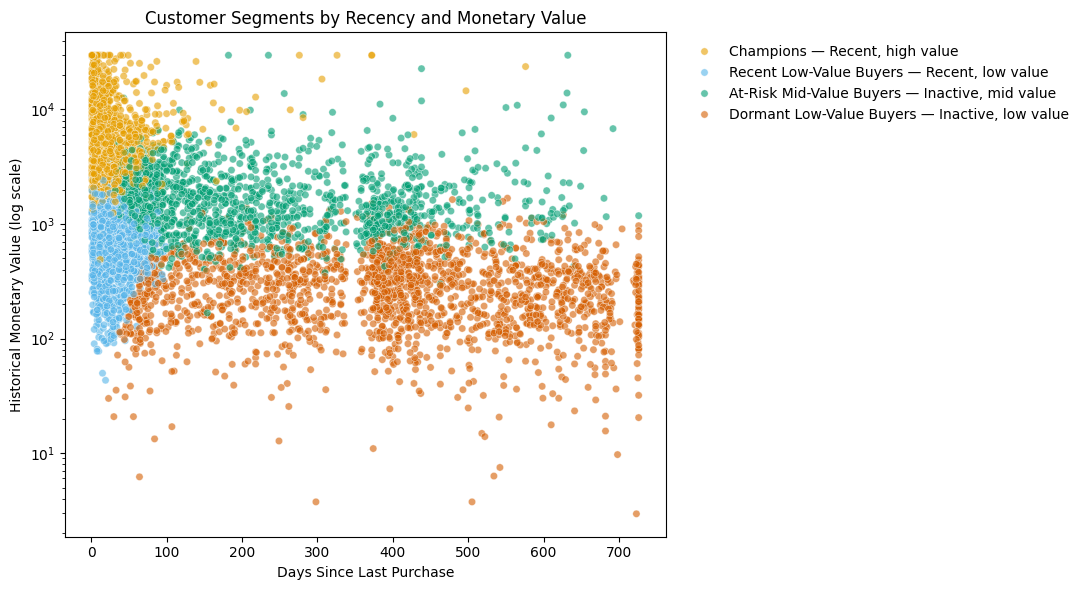

In [183]:
segment_order = [
    'Champions — Recent, high value',
    'Recent Low-Value Buyers — Recent, low value',
    'At-Risk Mid-Value Buyers — Inactive, mid value',
    'Dormant Low-Value Buyers — Inactive, low value'
]

segment_colors = {
    'Champions — Recent, high value': "#E69F00",
    'Recent Low-Value Buyers — Recent, low value': "#56B4E9",
    'At-Risk Mid-Value Buyers — Inactive, mid value': "#009E73",
    'Dormant Low-Value Buyers — Inactive, low value': "#D55E00"
}

plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=df,
    x='recency',
    y='monetary',
    hue='segment',
    hue_order=segment_order,
    palette=segment_colors,
    alpha=0.60,
    s=28
)

plt.yscale('log')

plt.title('Customer Segments by Recency and Monetary Value')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Historical Monetary Value (log scale)')

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.show()

In [166]:
# Stability Analysis

rng = np.random.default_rng(42)
stability_scores = []

base_model = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

base_labels = base_model.fit_predict(X_processed)

for seed in range(10):
    sample_idx = rng.choice(
        len(X_processed),
        size=int(0.8 * len(X_processed)),
        replace=False
    )

    model = KMeans(
        n_clusters=4,
        random_state=seed,
        n_init=20
    )

    sample_labels = model.fit_predict(X_processed[sample_idx])

    score = adjusted_rand_score(
        base_labels[sample_idx],
        sample_labels
    )

    stability_scores.append(score)

np.mean(stability_scores), np.std(stability_scores)

(np.float64(0.9799695449055136), np.float64(0.00607571311483357))

In [167]:
stability_summary = {
    'mean_ari': np.mean(stability_scores),
    'std_ari': np.std(stability_scores),
    'min_ari': np.min(stability_scores),
    'max_ari': np.max(stability_scores),
    'n_runs': len(stability_scores),
    'sample_fraction': 0.80
}

pd.Series(stability_summary).round(4)

mean_ari            0.9800
std_ari             0.0061
min_ari             0.9661
max_ari             0.9854
n_runs             10.0000
sample_fraction     0.8000
dtype: float64

In [168]:
# Naming the Clusters

segment_names = {
    0: 'Recent low-value buyers',
    1: 'Champions',
    2: 'At-risk mid-value customers',
    3: 'Dormant low-value customers'
}

df['segment'] = df['cluster_k4'].map(segment_names)

df['segment'].value_counts()

segment
Dormant low-value customers    1964
At-risk mid-value customers    1457
Recent low-value buyers        1238
Champions                      1219
Name: count, dtype: int64

In [169]:
behaviour_profile = (
    df
    .groupby('segment')
    .agg(
        customers=('CustomerID', 'count'),
        weekend_share_median=('weekend_share', 'median'),
        average_purchase_hour_median=('avg_purchase_hour', 'median'),
        active_purchase_days_median=('active_purchase_days', 'median'),
        days_between_orders_median=('avg_days_between_orders', 'median'),
        order_dates_median=('order_date_count', 'median')
    )
    .round(2)
)

behaviour_profile

,customers,weekend_share_median,average_purchase_hour_median,active_purchase_days_median,days_between_orders_median,order_dates_median
segment,,,,,,
At-risk mid-value customers,1457,0.00,12.50,4.0,88.30,4.0
Champions,1219,0.09,12.42,12.0,45.78,13.0
Dormant low-value customers,1964,0.00,13.00,1.0,99.56,1.0
Recent low-value buyers,1238,0.00,12.60,3.0,113.23,3.0


In [170]:
interorder_coverage = (
    df
    .groupby('segment')['avg_days_between_orders']
    .agg(
        valid_values='count',
        missing_values=lambda x: x.isna().sum(),
        median='median'
    )
    .round(2)
)

interorder_coverage

,valid_values,missing_values,median
segment,,,
At-risk mid-value customers,1435,22,88.30
Champions,1219,0,45.78
Dormant low-value customers,600,1364,99.56
Recent low-value buyers,999,239,113.23


In [171]:
order_counts = (
    df
    .groupby('segment')['order_date_count']
    .agg(
        valid_values='count',
        missing_values=lambda x: x.isna().sum(),
        median='median'
    )
    .round(2)
)

order_counts

,valid_values,missing_values,median
segment,,,
At-risk mid-value customers,1457,0,4.0
Champions,1219,0,13.0
Dormant low-value customers,1964,0,1.0
Recent low-value buyers,1238,0,3.0


In [172]:
weekend_coverage = (
    df
    .groupby('segment')['weekend_share']
    .agg(
        valid_values='count',
        missing_values=lambda x: x.isna().sum(),
        median='median'
    )
    .round(2)
)

weekend_coverage

,valid_values,missing_values,median
segment,,,
At-risk mid-value customers,1457,0,0.00
Champions,1219,0,0.09
Dormant low-value customers,1964,0,0.00
Recent low-value buyers,1238,0,0.00


In [173]:
time_profile = pd.crosstab(
    df['segment'],
    df['preferred_time_5cat'],
    normalize="index"
).mul(100).round(1)

time_profile

preferred_time_5cat,afternoon,evening,midday,morning
segment,,,,
At-risk mid-value customers,37.5,0.9,57.9,3.7
Champions,26.3,0.5,71.6,1.6
Dormant low-value customers,41.9,1.5,49.4,7.2
Recent low-value buyers,42.5,1.1,52.3,4.1


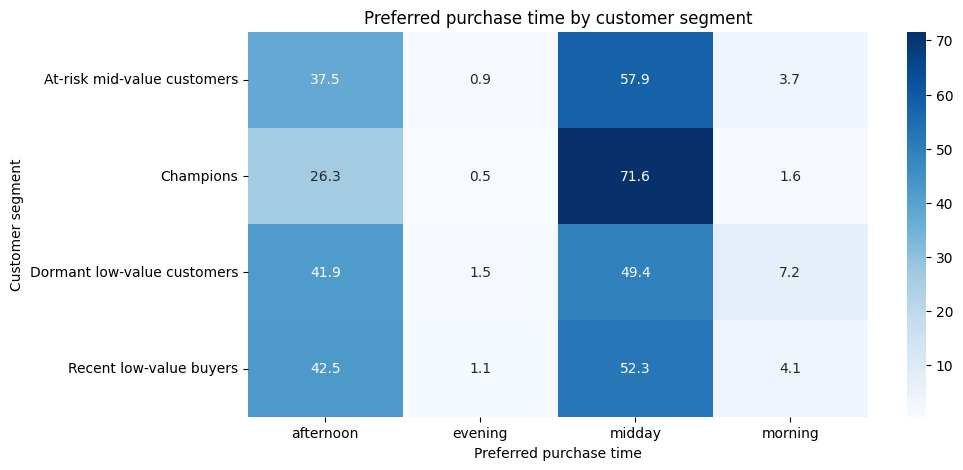

In [174]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    time_profile,
    annot=True,
    fmt='.1f',
    cmap='Blues'
)

plt.title('Preferred purchase time by customer segment')
plt.xlabel('Preferred purchase time')
plt.ylabel('Customer segment')
plt.show()

In [175]:
month_profile = pd.crosstab(
    df['segment'],
    df['preferred_month_period'],
    normalize='index'
).mul(100).round(1)

month_profile

preferred_month_period,beginning,end,middle
segment,,,
At-risk mid-value customers,44.3,31.2,24.4
Champions,44.1,28.6,27.2
Dormant low-value customers,40.1,33.6,26.3
Recent low-value buyers,48.1,30.1,21.8


In [176]:
season_profile = pd.crosstab(
    df['segment'],
    df['preferred_season'],
    normalize='index'
).mul(100).round(1)

season_profile

preferred_season,autumn,spring,summer,winter
segment,,,,
At-risk mid-value customers,40.6,26.4,19.1,13.9
Champions,59.8,13.9,12.8,13.5
Dormant low-value customers,36.6,26.5,18.6,18.3
Recent low-value buyers,85.9,4.8,4.2,5.2


In [177]:
df.columns

Index(['CustomerID', 'recency', 'frequency', 'monetary', 'weekend_share',
       'avg_purchase_hour', 'preferred_hour', 'preferred_weekday',
       'active_purchase_days', 'preferred_time_5cat', 'preferred_season',
       'preferred_month_period', 'avg_days_between_orders', 'order_date_count',
       'text_svd_00', 'text_svd_01', 'text_svd_02', 'text_svd_03',
       'text_svd_04', 'text_svd_05', 'text_svd_06', 'text_svd_07',
       'text_svd_08', 'text_svd_09', 'text_svd_10', 'text_svd_11',
       'text_svd_12', 'text_svd_13', 'text_svd_14', 'recency_log',
       'frequency_log', 'monetary_log', 'recency_log_cap', 'frequency_log_cap',
       'monetary_log_cap', 'cluster_k2', 'cluster_k4', 'segment'],
      dtype='str')

In [178]:
weekday_profile = pd.crosstab(
    df['segment'],
    df['preferred_weekday'],
    normalize='index'
).mul(100).round(1)

weekday_profile

preferred_weekday,0,1,2,3,4,5,6
segment,,,,,,,
At-risk mid-value customers,24.2,22.4,17.8,18.8,7.6,0.0,9.1
Champions,18.5,20.3,19.8,22.9,9.2,0.0,9.4
Dormant low-value customers,18.9,19.5,19.3,18.4,11.6,0.1,12.3
Recent low-value buyers,23.9,22.6,17.5,17.0,9.0,0.0,10.0


### Robust RFM + NLP

In [179]:
# Features Selection - Robust RFM + SVD

svd = [f'text_svd_{i:02d}' for i in range(15)]

X = df[rfm_log_cap + svd] 

preprocess = ColumnTransformer([
    ('scaler', StandardScaler(), rfm_log_cap),
    ('passthrough', 'passthrough', svd) 
])

X_processed = preprocess.fit_transform(X)

n_components_to_test = range(2, 10)

inertias = []
silhouettes = []

for n in n_components_to_test:
    model = KMeans(n_clusters=n, random_state=42, n_init="auto")
    labels = model.fit_predict(X_processed)

    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_processed, labels))

results = pd.DataFrame({
    'k': list(n_components_to_test),
    'inertia': inertias,
    'silhouette': silhouettes
})

results

,k,inertia,silhouette
0,2,10594.144939,0.382727
1,3,8341.150973,0.277945
2,4,6882.809070,0.284772
3,5,6106.800401,0.241222
4,6,5540.518939,0.236694
5,7,5175.694534,0.199071
6,8,4889.451730,0.197122
7,9,4650.154402,0.184848


### RFM Model with NLP & Behaviour data

In [180]:
inertias = []
silhouettes = []

beh_num_col = [
    'weekend_share',
    'avg_purchase_hour',
    'preferred_hour',
    'active_purchase_days',
    'avg_days_between_orders',
    'order_date_count'
]

beh_cat_col = ['preferred_time_5cat', 'preferred_month_period', 'preferred_season']

X = df[rfm_log_cap + beh_num_col + beh_cat_col]

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[
        ('rfm', numeric_pipeline, rfm_log_cap),
        ('beh', numeric_pipeline, beh_num_col),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), beh_cat_col),
    ]
)

X_processed = preprocess.fit_transform(X)

n_components_to_test = range(2, 9)

for n in n_components_to_test:
    model = KMeans(n_clusters=n, random_state=42, n_init='auto')
    labels = model.fit_predict(X_processed)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_processed, labels))

results = pd.DataFrame({
    'k': list(n_components_to_test),
    'inertia': inertias,
    'silhouette': silhouettes
})

print(results)


   k       inertia  silhouette
0  2  51404.412039    0.202524
1  3  44416.939752    0.178710
2  4  40645.052563    0.197626
3  5  35768.022971    0.203363
4  6  32684.826730    0.209294
5  7  29936.747131    0.194648
6  8  28610.747545    0.167224



Behavioural and temporal features did not improve the separation of customer-value segments when included directly in K-Means clustering. They were therefore retained for post-clustering profiling and campaign activation rather than used as inputs to the final segmentation model.

### Further Analysis

In [181]:
df.columns

Index(['CustomerID', 'recency', 'frequency', 'monetary', 'weekend_share',
       'avg_purchase_hour', 'preferred_hour', 'preferred_weekday',
       'active_purchase_days', 'preferred_time_5cat', 'preferred_season',
       'preferred_month_period', 'avg_days_between_orders', 'order_date_count',
       'text_svd_00', 'text_svd_01', 'text_svd_02', 'text_svd_03',
       'text_svd_04', 'text_svd_05', 'text_svd_06', 'text_svd_07',
       'text_svd_08', 'text_svd_09', 'text_svd_10', 'text_svd_11',
       'text_svd_12', 'text_svd_13', 'text_svd_14', 'recency_log',
       'frequency_log', 'monetary_log', 'recency_log_cap', 'frequency_log_cap',
       'monetary_log_cap', 'cluster_k2', 'cluster_k4', 'segment'],
      dtype='str')